# Редактирование состояния графа (graph state)

## Обзор

Мы рассмотрели причины для реализации принципа "человек в цикле" (human-in-the-loop):

1. **Подтверждение (Approval)** - Возможность прервать агент, отобразить состояние для пользователя и получить подтверждение действия
2. **Отладка (Debugging)** - Возможность перемотки графа для воспроизведения или избежания проблем
3. **Редактирование (Editing)** - Возможность модификации состояния

Мы показали как точки останова (breakpoints) поддерживают подтверждение пользователем, но ещё не разобрали как модифицировать состояние графа после прерывания!

## Цели

Сейчас мы покажем как напрямую редактировать состояние графа (graph state) и вносить обратную связь от человека.

_______________________________________________________________

In [1]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage
from langchain_gigachat import GigaChat

import os
api_key = os.getenv("GIGA_API_KEY")

llm = model = GigaChat(
    credentials = api_key,
    verify_ssl_certs=False,
    scope = 'GIGACHAT_API_CORP',
    temperature=0.0,
    profanity_check = False,
    model="GigaChat",
)

## Редактирование состояния (Editing state)

Ранее мы представили точки останова (breakpoints).

Мы использовали их для прерывания графа и ожидания подтверждения пользователя перед выполнением следующего узла (node).

Но точки останова также представляют [возможности для изменения состояния графа](https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/edit-graph-state/) (graph state).

Давайте настроим нашего агента с точкой останова перед узлом `assistant`.

In [2]:

def multiply(a: int, b: int) -> int:
    """Умножает a на b.

    Args:
        a: первое число
        b: второе число
    """
    return a * b

# Это будет инструментом (tool)
def add(a: int, b: int) -> int:
    """Складывает a и b.

    Args:
        a: первое число
        b: второе число
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Делит a на b.

    Args:
        a: первое число
        b: второе число
    """
    return a / b

tools = [add, multiply, divide]
llm_with_tools = llm.bind_tools(tools)

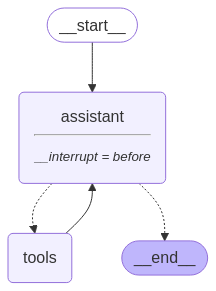

In [3]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import HumanMessage, SystemMessage

# Системное сообщение
sys_msg = SystemMessage(content="Вы помощник, выполняющий арифметические операции над входными данными.")

# Узел (node)
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Граф (graph)
builder = StateGraph(MessagesState)

# Определяем узлы: они выполняют работу
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Определяем связи: они управляют потоком выполнения
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # Если последнее сообщение от assistant содержит вызов инструмента (tool call) -> tools_condition перенаправляет в tools
    # Если последнее сообщение от assistant не содержит вызов инструмента -> tools_condition перенаправляет в END
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(interrupt_before=["assistant"], checkpointer=memory)

# Отображение
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [4]:
# Входные данные (Input)
initial_input = {"messages": "Умножьте 2 на 3"}

# Поток выполнения (Thread)
thread = {"configurable": {"thread_id": "1"}}

# Запускаем граф до первого прерывания
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Умножьте 2 на 3


In [5]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='Умножьте 2 на 3', additional_kwargs={}, response_metadata={}, id='b0a958ea-95d4-423b-8981-f926c036a970')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f00bd2d-4f52-6a1d-8000-c4f37e19412b'}}, metadata={'source': 'loop', 'writes': None, 'thread_id': '1', 'step': 0, 'parents': {}}, created_at='2025-03-28T12:47:39.235996+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f00bd2d-4f50-6176-bfff-eb807c45222e'}}, tasks=(PregelTask(id='d8465fd7-d55b-1485-706a-fd07793fb5a2', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),))

===================================================================================================================

Теперь мы можем напрямую применять обновление состояния (state update).

Помните, что обновления ключа `messages` используют редьюсер (reducer) `add_messages`:

* Если мы хотим перезаписать существующее сообщение, мы можем указать `id` сообщения
* Если мы просто хотим добавить новое сообщение в список, мы можем передать сообщение без указания `id`, как показано ниже

In [6]:
graph.update_state(
    thread,
    {"messages": [HumanMessage(content="Нет, перемножь 3 и 3!")]},
)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f00bd2d-4f75-6ad8-8001-52230f49847e'}}

Посмотрим результат.

Мы выполнили `update_state` с новым сообщением.

Редьюсер (reducer) `add_messages` добавил его в указанный ключ состояния (state key) `messages`.

In [7]:
new_state = graph.get_state(thread).values
for m in new_state['messages']:
    m.pretty_print()

================================ Human Message =================================

Умножьте 2 на 3
================================ Human Message =================================

Нет, перемножь 3 и 3!


Продолжим выполнение агента (agent), передав `None` - это позволит продолжить работу из текущего состояния (current state).

Мы:
1. Выводим текущее состояние
2. Выполняем оставшиеся узлы графа (remaining nodes)

In [8]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Нет, перемножь 3 и 3!
================================== Ai Message ==================================
Tool Calls:
  multiply (ed9e899c-5a43-4882-a826-1574852a91f0)
 Call ID: ed9e899c-5a43-4882-a826-1574852a91f0
  Args:
    a: 3
    b: 3
================================= Tool Message =================================
Name: multiply

9


Сейчас мы вернулись в узел `assistant`, где установлена наша точка останова (breakpoint).

Можем снова передать `None` для продолжения выполнения.

In [9]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

9
================================== Ai Message ==================================

Результат умножения 3 на 3 равен 9.


## Ожидание пользовательского ввода (Awaiting user input)

Теперь очевидно, что мы можем редактировать состояние агента (agent state) после точки останова (breakpoint).

Но что если мы хотим получить обратную связь от пользователя (human feedback) для выполнения этого обновления состояния?

Мы добавим узел [human_feedback](https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/wait-user-input/#setup), который будет выступать в качестве placeholder для пользовательского ввода.

Этот узел `human_feedback` позволяет пользователю напрямую добавлять обратную связь в состояние.

Мы указываем точку останова с помощью `interrupt_before` перед нашим узлом `human_feedback`.

Настраиваем checkpointer для сохранения состояния графа до этого узла.

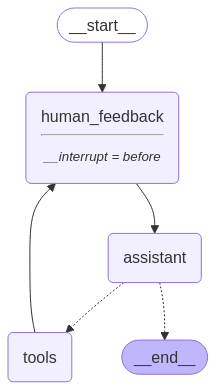

In [10]:
# Системное сообщение (System message)
sys_msg = SystemMessage(content="Вы помощник, выполняющий арифметические операции над входными данными.")

# Пустой узел (no-op node), который должен прерываться
def human_feedback(state: MessagesState):
    pass

# Узел ассистента (Assistant node)
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Граф (Graph)
builder = StateGraph(MessagesState)

# Определение узлов (Define nodes)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_node("human_feedback", human_feedback)

# Определение связей (Define edges)
builder.add_edge(START, "human_feedback")
builder.add_edge("human_feedback", "assistant")
builder.add_conditional_edges(
    "assistant",
    # Если последнее сообщение от assistant содержит вызов инструмента -> переход к tools
    # Если не содержит вызова инструмента -> переход к END
    tools_condition,
)
builder.add_edge("tools", "human_feedback")

memory = MemorySaver()
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

Получаем обратную связь от пользователя (human feedback).

Используем `.update_state` для обновления состояния графа (graph state) полученным ответом, как и ранее.

Параметр `as_node="human_feedback"` применяет это обновление состояния к указанному узлу `human_feedback`.

In [11]:
# Входные данные
initial_input = {"messages": "Умножь 2 на 3"}

# Поток выполнения
thread = {"configurable": {"thread_id": "5"}}

# Запускаем граф до первого прерывания
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()
    
# Получаем ввод пользователя
user_input = input("Укажите как обновить состояние: ")

# Обновляем состояние как если бы это был узел human_feedback
graph.update_state(thread, {"messages": user_input}, as_node="human_feedback")

# Продолжаем выполнение графа
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Умножь 2 на 3


Укажите как обновить состояние:  Переделай нахуй все. Нужно 4 на 4 умножить


================================ Human Message =================================

Переделай нахуй все. Нужно 4 на 4 умножить
================================== Ai Message ==================================
Tool Calls:
  multiply (01e24bc1-236d-4094-8df2-4126de90fc74)
 Call ID: 01e24bc1-236d-4094-8df2-4126de90fc74
  Args:
    a: 4
    b: 4
================================= Tool Message =================================
Name: multiply

16


In [12]:
# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

16
================================== Ai Message ==================================

Результат умножения 4 на 4 равен 16.
